# Lab 03: Gauss-Newton Optimisation — SOLUTIONS

**Course:** 12062 Algorithmic Robotics  
**Lab Session:** Week 4  
**Duration:** 90 minutes (after 30-min board derivation)  
**Prerequisites:** Lecture 4 (Sections 4.3–4.7)

---

## What You Just Derived on the Board

You walked through Gauss-Newton for the **triangulation problem** (Example 4.2, Section 4.7). The key steps were:

1. Compute model predictions $h(\mathbf{x})$ and residuals $\mathbf{e} = \mathbf{z} - h(\mathbf{x})$
2. Compute the Jacobian $J$ (partial derivatives of $h$ w.r.t. $\mathbf{x}$)
3. Solve the normal equations $J^T J \, \boldsymbol{\delta} = J^T \mathbf{e}$ for the step $\boldsymbol{\delta}$
4. Update $\mathbf{x}_{k+1} = \mathbf{x}_k + \boldsymbol{\delta}$
5. Repeat until convergence

Now you will implement this yourself.

---

## The Problem

Three trees at known positions. You measure your range to each. Estimate your position.

| Landmark | Position |
|----------|----------|
| Tree A   | (0, 0)   |
| Tree B   | (10, 0)  |
| Tree C   | (5, 8)   |

- **Measurements:** $\mathbf{z} = [5.1,\; 6.7,\; 5.3]$ (noisy ranges)
- **Model:** $h_i(\mathbf{x}) = \sqrt{(L_{i,1} - x_1)^2 + (L_{i,2} - x_2)^2}$
- **Unknown:** $\mathbf{x} = [x_1, x_2]$ (your position)
- **True position:** $(4, 3)$
- **Initial guess:** $\mathbf{x}_0 = [1, 1]$

---

## Lab Structure

| Part | Time | What You Do |
|------|------|-------------|
| **Part 1** | 45 min | Implement Gauss-Newton from scratch using only NumPy |
| **Part 2** | 45 min | Solve the same problem using `scipy.sparse` and `spsolve` — the same tools our SLAM optimizer uses |

![Triangulation: Range Measurements to Known Landmarks](L4_Figure_01_Triangulation_Problem.png)

---

## Section 0: Setup & Imports — 2 min

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

print("All imports successful.")

All imports successful.


---

## Section 1: Define the Problem — 5 min

### Exercise 1.1: Problem Data

Store the landmarks, measurements, initial guess, and true position as NumPy arrays.

In [4]:
# Landmark positions (each row is one landmark [x, y])
landmarks = np.array([
    [0.0,  0.0],   # Tree A
    [10.0, 0.0],   # Tree B
    [5.0,  8.0],   # Tree C
])

# Noisy range measurements
z = np.array([5.1, 6.7, 5.3])

# Initial guess and true position
x0 = np.array([1.0, 1.0])
x_true = np.array([4.0, 3.0])

print(f"Landmarks:\n{landmarks}")
print(f"Measurements: {z}")
print(f"Initial guess: {x0}")
print(f"True position: {x_true}")

Landmarks:
[[ 0.  0.]
 [10.  0.]
 [ 5.  8.]]
Measurements: [5.1 6.7 5.3]
Initial guess: [1. 1.]
True position: [4. 3.]


### Exercise 1.2: Visualise the Setup

Plot the landmarks, the true position, and the initial guess. Draw range circles (centred on each landmark with radius = measured range) to see where they intersect.

> **Hint:** Use `plt.Circle((cx, cy), radius, fill=False)` and `ax.add_patch(circle)` to draw circles.

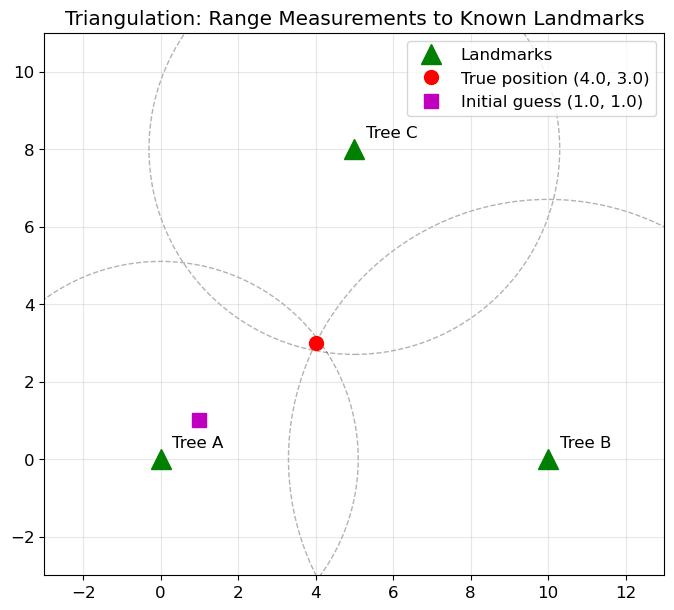

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot landmarks
ax.plot(landmarks[:, 0], landmarks[:, 1], 'g^', markersize=14, label='Landmarks')
for i, name in enumerate(['A', 'B', 'C']):
    ax.annotate(f'Tree {name}', landmarks[i] + [0.3, 0.3], fontsize=12)

# Plot true position and initial guess
ax.plot(*x_true, 'ro', markersize=10, label=f'True position {tuple(x_true)}')
ax.plot(*x0, 'ms', markersize=10, label=f'Initial guess {tuple(x0)}')

# SOLUTION — draw a range circle for each landmark/measurement pair
for i in range(3):
    circle = plt.Circle(landmarks[i], z[i], fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)

ax.set_xlim(-3, 13)
ax.set_ylim(-3, 11)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Triangulation: Range Measurements to Known Landmarks')
ax.grid(True, alpha=0.3)
plt.show()

---

# Part 1: Gauss-Newton from Scratch (NumPy only) — 45 min

You will implement each step of the Gauss-Newton algorithm using basic NumPy operations. No optimisation libraries allowed in this part.

## Step 1: The Measurement Model $h(\mathbf{x})$ — 5 min

### Exercise 1.3: Implement the model

Write a function that computes the predicted range from position $\mathbf{x}$ to each landmark.

$$h_i(\mathbf{x}) = \sqrt{(L_{i,1} - x_1)^2 + (L_{i,2} - x_2)^2}$$

> **Hint:** `np.sqrt(np.sum((landmarks - x)**2, axis=1))` computes all three distances in one line. Broadcasting handles the subtraction.

In [6]:
def predict_ranges(x, landmarks):
    """
    Compute predicted range from position x to each landmark.
    
    Args:
        x: position [x1, x2] — shape (2,)
        landmarks: landmark positions — shape (m, 2)
    
    Returns:
        h: predicted ranges — shape (m,)
    """
    # SOLUTION
    return np.sqrt(np.sum((landmarks - x)**2, axis=1))

# Test: predictions from the initial guess
h0 = predict_ranges(x0, landmarks)
print(f"Predicted ranges from x0 = {x0}: {h0}")
print(f"Measured ranges:                  {z}")
print(f"Residuals (z - h):                {z - h0}")

Predicted ranges from x0 = [1. 1.]: [1.41421356 9.05538514 8.06225775]
Measured ranges:                  [5.1 6.7 5.3]
Residuals (z - h):                [ 3.68578644 -2.35538514 -2.76225775]


## Step 2: The Jacobian $J$ (Provided)

The Jacobian is an $m \times n$ matrix ($m = 3$ measurements, $n = 2$ unknowns). You derived this on the board:

$$J[i, 1] = \frac{-(L_{i,1} - x_1)}{h_i(\mathbf{x})} \qquad J[i, 2] = \frac{-(L_{i,2} - x_2)}{h_i(\mathbf{x})}$$

The function below computes this for you. **Read it, make sure you understand what each line does, then run the cell.**

In [7]:
def compute_jacobian(x, landmarks, h):
    """
    Compute the Jacobian of the range model.
    
    Each row points from the landmark toward x, normalised by range.
    
    Args:
        x: current position estimate [x1, x2] — shape (2,)
        landmarks: landmark positions — shape (m, 2)
        h: predicted ranges at x — shape (m,)
    
    Returns:
        J: Jacobian matrix — shape (m, 2)
    """
    diff = x - landmarks                  # (m, 2): vector from each landmark to x
    J = diff / h.reshape(-1, 1)           # normalise each row by the predicted range
    return J

# Test: Jacobian at initial guess
J0 = compute_jacobian(x0, landmarks, h0)
print(f"Jacobian at x0:\n{J0}")
print(f"\nShape: {J0.shape} (should be (3, 2))")

Jacobian at x0:
[[ 0.70710678  0.70710678]
 [-0.99388373  0.11043153]
 [-0.49613894 -0.86824314]]

Shape: (3, 2) (should be (3, 2))


## Step 3: Solve the Normal Equations — 10 min

### Exercise 1.6: One Gauss-Newton Step

Compute one Gauss-Newton update:

1. Residual: $\mathbf{e} = \mathbf{z} - h(\mathbf{x}_k)$
2. Normal equations: $J^T J \, \boldsymbol{\delta} = J^T \mathbf{e}$
3. Update: $\mathbf{x}_{k+1} = \mathbf{x}_k + \boldsymbol{\delta}$

> **Hint:** Use `np.linalg.solve(A, b)` to solve $A\boldsymbol{\delta} = \mathbf{b}$. Here $A = J^T J$ and $\mathbf{b} = J^T \mathbf{e}$.

In [8]:
x_k = x0.copy()

# Step 1: Compute predictions and residuals
h_k = predict_ranges(x_k, landmarks)
e_k = z - h_k  # SOLUTION

# Step 2: Compute Jacobian
J_k = compute_jacobian(x_k, landmarks, h_k)

# Step 3: Build and solve normal equations
H = J_k.T @ J_k                        # SOLUTION
b = J_k.T @ e_k                         # SOLUTION
delta = np.linalg.solve(H, b)           # SOLUTION

# Step 4: Update
x_new = x_k + delta                     # SOLUTION

print(f"Before: x = {x_k}")
print(f"Step:   \u03b4 = {delta}")
print(f"After:  x = {x_new}")
print(f"Cost:   {np.sum(e_k**2):.4f} \u2192 {np.sum((z - predict_ranges(x_new, landmarks))**2):.4f}")

Before: x = [1. 1.]
Step:   δ = [2.69734243 1.99827103]
After:  x = [3.69734243 2.99827103]
Cost:   26.7629 → 0.2108


## Step 4: Full Gauss-Newton Loop — 10 min

### Exercise 1.7: Iterate Until Convergence

Put steps 1–3 in a loop. Stop when either:
- The step is tiny: $\|\boldsymbol{\delta}\| < 10^{-8}$
- You hit `max_iter = 20` iterations

Store the estimate and cost at each iteration for plotting.

> **Hint:** `np.linalg.norm(delta)` computes $\|\boldsymbol{\delta}\|$.

In [9]:
def gauss_newton(x0, landmarks, z, max_iter=20, tol=1e-8):
    """
    Run Gauss-Newton optimisation for the triangulation problem.
    
    Returns:
        x: final estimate
        history: list of (x, cost) at each iteration
    """
    x = x0.copy()
    history = []
    
    for k in range(max_iter):
        # SOLUTION
        # 1. Compute h, e, cost
        h = predict_ranges(x, landmarks)
        e = z - h
        cost = np.sum(e**2)
        
        # 2. Store history
        history.append((x.copy(), cost))
        
        # 3. Compute Jacobian
        J = compute_jacobian(x, landmarks, h)
        
        # 4. Solve normal equations
        H = J.T @ J
        b = J.T @ e
        delta = np.linalg.solve(H, b)
        
        # 5. Update
        x = x + delta
        
        print(f"Iter {k}: x = [{x[0]:.6f}, {x[1]:.6f}], cost = {cost:.6f}, |\u03b4| = {np.linalg.norm(delta):.2e}")
        
        # 6. Check convergence
        if np.linalg.norm(delta) < tol:
            print(f"Converged at iteration {k}")
            break
    
    # Store final state
    h_final = predict_ranges(x, landmarks)
    history.append((x.copy(), np.sum((z - h_final)**2)))
    
    return x, history

x_est, history = gauss_newton(x0, landmarks, z)

print(f"\nFinal estimate: x\u0302 = [{x_est[0]:.6f}, {x_est[1]:.6f}]")
print(f"True position:  x = {x_true}")
print(f"Error:          {np.linalg.norm(x_est - x_true):.6f} m")

Iter 0: x = [3.697342, 2.998271], cost = 26.762929, |δ| = 3.36e+00
Iter 1: x = [4.046908, 2.896864], cost = 0.210811, |δ| = 3.64e-01
Iter 2: x = [4.052912, 2.895600], cost = 0.033278, |δ| = 6.14e-03
Iter 3: x = [4.053057, 2.895513], cost = 0.033224, |δ| = 1.69e-04
Iter 4: x = [4.053061, 2.895510], cost = 0.033224, |δ| = 5.22e-06
Iter 5: x = [4.053061, 2.895510], cost = 0.033224, |δ| = 1.63e-07
Iter 6: x = [4.053061, 2.895510], cost = 0.033224, |δ| = 5.12e-09
Converged at iteration 6

Final estimate: x̂ = [4.053061, 2.895510]
True position:  x = [4. 3.]
Error:          0.117191 m


## Step 5: Visualise Convergence — 10 min

### Exercise 1.8: Plot the Iteration Path and Cost

Create a 1×2 figure:
- **Left:** The triangulation setup with the Gauss-Newton iterates plotted as connected points
- **Right:** Cost vs iteration (use log scale for y-axis)

> **Hint:** Extract iterates with `xs = np.array([h[0] for h in history])` and costs with `costs = [h[1] for h in history]`. Use `ax.semilogy()` for log-scale y-axis.

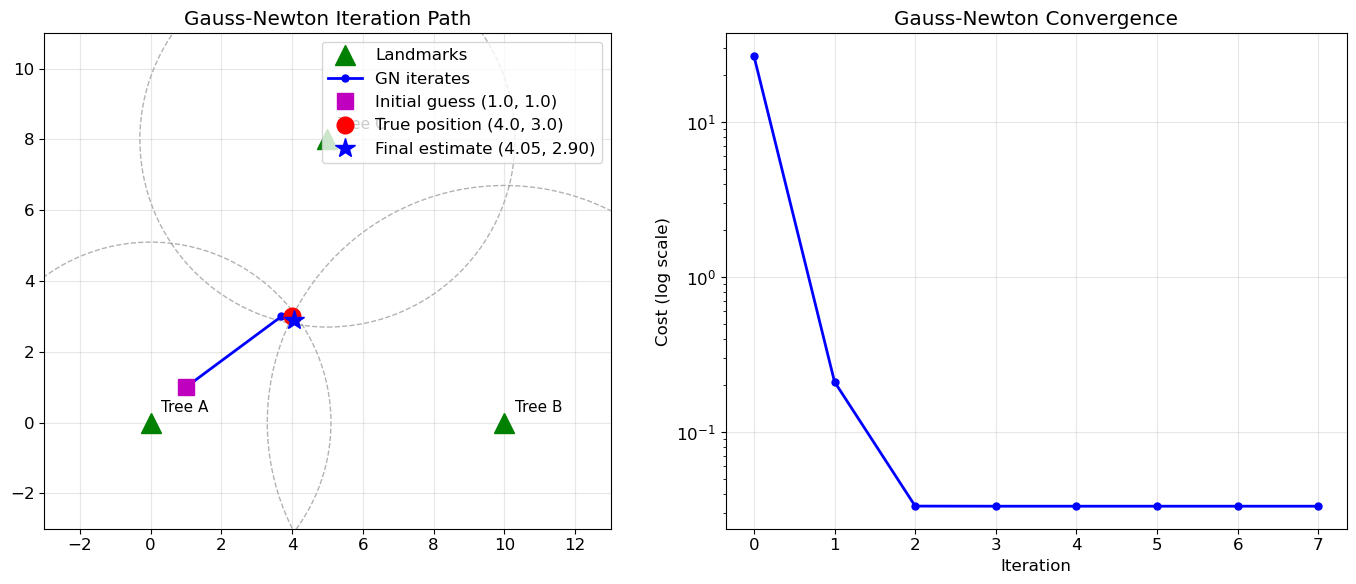

In [10]:
xs = np.array([h[0] for h in history])
costs = [h[1] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: iteration path ---
# Plot landmarks
ax1.plot(landmarks[:, 0], landmarks[:, 1], 'g^', markersize=14, label='Landmarks')
for i, name in enumerate(['A', 'B', 'C']):
    ax1.annotate(f'Tree {name}', landmarks[i] + [0.3, 0.3], fontsize=11)

# Plot range circles
for i in range(3):
    circle = plt.Circle(landmarks[i], z[i], fill=False, linestyle='--', alpha=0.3)
    ax1.add_patch(circle)

# SOLUTION — plot the iterates as connected points, true position, final estimate
ax1.plot(xs[:, 0], xs[:, 1], 'b.-', markersize=10, linewidth=2, label='GN iterates')
ax1.plot(*xs[0], 'ms', markersize=12, label=f'Initial guess {tuple(x0)}')
ax1.plot(*x_true, 'ro', markersize=12, label=f'True position {tuple(x_true)}')
ax1.plot(*xs[-1], 'b*', markersize=15, label=f'Final estimate ({xs[-1][0]:.2f}, {xs[-1][1]:.2f})')

ax1.set_xlim(-3, 13)
ax1.set_ylim(-3, 11)
ax1.set_aspect('equal')
ax1.legend()
ax1.set_title('Gauss-Newton Iteration Path')
ax1.grid(True, alpha=0.3)

# --- Right panel: cost convergence ---
# SOLUTION
ax2.semilogy(range(len(costs)), costs, 'b.-', markersize=10, linewidth=2)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost (log scale)')
ax2.set_title('Gauss-Newton Convergence')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Checkpoint

Before moving on, verify:
- Your estimate is close to (4, 3)
- The cost drops by several orders of magnitude
- Convergence happens in about 4–6 iterations

If not, go back and check your Jacobian — sign errors are the #1 bug.

---

# Part 2: Gauss-Newton with Sparse Matrices and `spsolve` — 45 min

In Part 1, you solved $J^T J \, \boldsymbol{\delta} = J^T \mathbf{e}$ using `np.linalg.solve`. This works for 2 unknowns, but SLAM has **thousands** of unknowns (3 per pose). The $H$ matrix is mostly zeros because each measurement only connects a few poses.

Our SLAM optimizer in `graph_optimizer.py` uses:
- `scipy.sparse.lil_matrix` to build $H$ incrementally
- `.tocsc()` to convert to compressed format
- `scipy.sparse.linalg.spsolve` to solve the system efficiently

You will now solve the **exact same triangulation problem** using these tools, so that the transition to the full SLAM code feels familiar.

### Why Sparse?

| | This lab (triangulation) | SLAM (Week 6+) |
|---|---|---|
| Unknowns | 2 (x, y) | 3 per pose × 100+ poses = 300+ |
| $H$ size | 2×2 | 300×300 (mostly zeros) |
| Solver | `np.linalg.solve` works fine | `spsolve` is necessary |

For 2 unknowns, sparse is overkill. The point is to **practise the pattern** so it's not new when you hit the real thing.

## Step 1: Build H and b One Measurement at a Time — 15 min

### Exercise 2.1: The Per-Measurement Contribution

In SLAM, each edge (measurement) contributes independently to $H$ and $\mathbf{b}$:

$$H \mathrel{+}= J_i^T \, \Omega_i \, J_i \qquad \mathbf{b} \mathrel{+}= J_i^T \, \Omega_i \, e_i$$

where $J_i$ is the Jacobian row for measurement $i$, $\Omega_i$ is the information (weight) for that measurement, and $e_i$ is the scalar residual.

For our problem with equal noise on all measurements, $\Omega_i = 1$ (identity weighting). The Jacobian row for measurement $i$ is $J_i = J[i, :]$, a $1 \times 2$ vector.

So the contribution of measurement $i$ is:
$$H \mathrel{+}= J_i^T J_i \qquad \mathbf{b} \mathrel{+}= J_i^T \, e_i$$

Write a function that builds $H$ and $\mathbf{b}$ by looping over measurements and accumulating these contributions into a sparse matrix.

> **Hint:** 
> - Create `H = sparse.lil_matrix((n, n))` where `n = 2`
> - For each measurement $i$: `Ji = J[i, :].reshape(1, -1)` gives a (1, 2) row
> - `Ji.T @ Ji` is a (2, 2) outer product — add it to `H`
> - `Ji.T.flatten() * e[i]` gives the contribution to `b`

In [ ]:
def build_sparse_system(x, landmarks, z):
    """
    Build the H matrix (sparse) and b vector by accumulating
    per-measurement contributions.
    
    This mirrors the structure of graph_optimizer.py, where each
    edge adds its contribution to the global H and b.
    
    Returns:
        H: sparse lil_matrix (n x n)
        b: dense vector (n,)
        total_cost: sum of squared residuals
    """
    n = len(x)  # number of unknowns
    m = len(z)  # number of measurements
    
    H = sparse.lil_matrix((n, n))
    b = np.zeros(n)
    total_cost = 0.0
    
    # Compute predictions and Jacobian at current estimate
    h = predict_ranges(x, landmarks)
    J = compute_jacobian(x, landmarks, h)
    
    # Loop over each measurement (like looping over edges in SLAM)
    for i in range(m):
        # SOLUTION
        e_i = z[i] - h[i]
        Ji = J[i, :].reshape(1, -1)
        H += Ji.T @ Ji
        b += Ji.T.flatten() * e_i
        total_cost += e_i**2
    
    return H, b, total_cost

# Test
H_test, b_test, cost_test = build_sparse_system(x0, landmarks, z)
print(f"H (dense view):\n{H_test.toarray()}")
print(f"b: {b_test}")
print(f"Cost: {cost_test:.4f}")

### Exercise 2.2: Verify Against Part 1

Check that the sparse $H$ and $\mathbf{b}$ match the dense $J^T J$ and $J^T \mathbf{e}$ from Part 1.

> **Hint:** `H.toarray()` converts the sparse matrix to dense for comparison.

In [ ]:
# Recompute the dense version from Part 1
h_check = predict_ranges(x0, landmarks)
e_check = z - h_check
J_check = compute_jacobian(x0, landmarks, h_check)

H_dense = J_check.T @ J_check
b_dense = J_check.T @ e_check

print(f"H match: {np.allclose(H_test.toarray(), H_dense)}")
print(f"b match: {np.allclose(b_test, b_dense)}")

## Step 2: Solve with `spsolve` — 10 min

### Exercise 2.3: One Iteration with spsolve

Convert $H$ to CSC format and solve $H \boldsymbol{\delta} = \mathbf{b}$ using `spsolve`.

This is exactly the pattern from `graph_optimizer.py` line 322:
```python
H_csc = H.tocsc()
dx = spsolve(H_csc, -b)
```

> **Note:** In our formulation, $\mathbf{b} = J^T \mathbf{e}$ already has the correct sign, so we solve $H \boldsymbol{\delta} = \mathbf{b}$.  
> In `graph_optimizer.py`, $\mathbf{b} = J^T \Omega \, \mathbf{e}$ is accumulated with the opposite sign convention, so it solves $H \, d\mathbf{x} = -\mathbf{b}$. Same maths, different sign bookkeeping.

In [ ]:
# Build the system at the initial guess
H_sp, b_sp, cost = build_sparse_system(x0, landmarks, z)

# Convert to CSC and solve
H_csc = H_sp.tocsc()                  # SOLUTION
delta_sp = spsolve(H_csc, b_sp)       # SOLUTION

x_new_sp = x0 + delta_sp

print(f"Step from spsolve: \u03b4 = {delta_sp}")
print(f"New estimate:      x = {x_new_sp}")
print(f"\nCompare with Part 1 (np.linalg.solve):")
print(f"They should match: {np.allclose(delta_sp, delta)}")

## Step 3: Full Loop with spsolve — 10 min

### Exercise 2.4: Complete Gauss-Newton with Sparse Solver

Write the full Gauss-Newton loop using `build_sparse_system` and `spsolve`.

> **Hint:** The structure is identical to Part 1, but replace:
> - `J.T @ J` → `build_sparse_system(...)` 
> - `np.linalg.solve(H, b)` → `spsolve(H.tocsc(), b)`

In [ ]:
def gauss_newton_sparse(x0, landmarks, z, max_iter=20, tol=1e-8):
    """
    Gauss-Newton using sparse H matrix and spsolve.
    Same algorithm as Part 1, different linear algebra backend.
    """
    x = x0.copy()
    history = []
    
    for k in range(max_iter):
        # SOLUTION
        # 1. Build sparse system
        H, b_vec, cost = build_sparse_system(x, landmarks, z)
        
        # 2. Store history
        history.append((x.copy(), cost))
        
        # 3. Print iteration info
        print(f"Iter {k}: x = [{x[0]:.6f}, {x[1]:.6f}], cost = {cost:.6f}")
        
        # 4. Convert to CSC and solve with spsolve
        H_csc = H.tocsc()
        delta = spsolve(H_csc, b_vec)
        
        # 5. Update
        x = x + delta
        
        # 6. Check convergence
        if np.linalg.norm(delta) < tol:
            print(f"Converged at iteration {k}")
            break
    
    # Store final state
    h_final = predict_ranges(x, landmarks)
    history.append((x.copy(), np.sum((z - h_final)**2)))
    
    return x, history

x_est_sp, history_sp = gauss_newton_sparse(x0, landmarks, z)

print(f"\nFinal estimate (sparse): [{x_est_sp[0]:.6f}, {x_est_sp[1]:.6f}]")
print(f"Final estimate (dense):  [{x_est[0]:.6f}, {x_est[1]:.6f}]")
print(f"Match: {np.allclose(x_est_sp, x_est)}")

## Step 4: Add Measurement Weights (Information Matrix) — 10 min

### Exercise 2.5: Weighted Least Squares

In SLAM, each measurement has an **information matrix** $\Omega_i = \Sigma_i^{-1}$ that encodes how much you trust it. The weighted contribution is:

$$H \mathrel{+}= J_i^T \, \Omega_i \, J_i \qquad \mathbf{b} \mathrel{+}= J_i^T \, \Omega_i \, e_i$$

For scalar measurements (like ranges), $\Omega_i = 1/\sigma_i^2$.

Modify `build_sparse_system` to accept a vector of measurement standard deviations. Make tree B's measurement noisier ($\sigma_B = 2.0$) while trees A and C stay precise ($\sigma = 0.5$).

> **Hint:** The only change is multiplying by $\omega_i = 1/\sigma_i^2$:
> - `H += omega_i * Ji.T @ Ji`
> - `b += omega_i * Ji.T.flatten() * e_i`
> - `cost += omega_i * e_i**2`

In [ ]:
def build_weighted_sparse_system(x, landmarks, z, sigmas):
    """
    Build sparse H and b with per-measurement weights.
    
    This matches graph_optimizer.py where each edge has its own Omega.
    
    Args:
        sigmas: measurement standard deviations — shape (m,)
    """
    n = len(x)
    m = len(z)
    
    H = sparse.lil_matrix((n, n))
    b = np.zeros(n)
    total_cost = 0.0
    
    h = predict_ranges(x, landmarks)
    J = compute_jacobian(x, landmarks, h)
    
    for i in range(m):
        # SOLUTION
        e_i = z[i] - h[i]
        Ji = J[i, :].reshape(1, -1)
        omega_i = 1.0 / sigmas[i]**2
        H += omega_i * (Ji.T @ Ji)
        b += omega_i * Ji.T.flatten() * e_i
        total_cost += omega_i * e_i**2
    
    return H, b, total_cost


def gauss_newton_weighted(x0, landmarks, z, sigmas, max_iter=20, tol=1e-8):
    """Gauss-Newton with weighted measurements."""
    x = x0.copy()
    history = []
    
    for k in range(max_iter):
        H, b_vec, cost = build_weighted_sparse_system(x, landmarks, z, sigmas)
        history.append((x.copy(), cost))
        
        delta = spsolve(H.tocsc(), b_vec)
        x = x + delta
        
        if np.linalg.norm(delta) < tol:
            history.append((x.copy(), np.sum(((z - predict_ranges(x, landmarks)) / sigmas)**2)))
            break
    
    return x, history


# Case 1: Equal weights
sigmas_equal = np.array([0.5, 0.5, 0.5])
x_equal, _ = gauss_newton_weighted(x0, landmarks, z, sigmas_equal)

# Case 2: Tree B is noisy
sigmas_noisy_b = np.array([0.5, 2.0, 0.5])
x_noisy_b, _ = gauss_newton_weighted(x0, landmarks, z, sigmas_noisy_b)

print(f"Equal weights:      x\u0302 = [{x_equal[0]:.4f}, {x_equal[1]:.4f}]")
print(f"Tree B noisy (\u03c3=2): x\u0302 = [{x_noisy_b[0]:.4f}, {x_noisy_b[1]:.4f}]")
print(f"\nThe estimate shifts because noisy Tree B gets less influence.")

### Exercise 2.6: Visualise the Effect of Weights

Plot both solutions (equal weights vs noisy Tree B) on the same figure.

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Landmarks and circles
ax.plot(landmarks[:, 0], landmarks[:, 1], 'g^', markersize=14, label='Landmarks')
for i, name in enumerate(['A', 'B', 'C']):
    ax.annotate(f'Tree {name}', landmarks[i] + [0.3, 0.3], fontsize=11)
for i in range(3):
    circle = plt.Circle(landmarks[i], z[i], fill=False, linestyle='--', alpha=0.3)
    ax.add_patch(circle)

ax.plot(*x_true, 'ro', markersize=12, label='True position')

# SOLUTION — plot x_equal and x_noisy_b with different markers and labels
ax.plot(*x_equal, 'b*', markersize=15, label=f'Equal weights ({x_equal[0]:.2f}, {x_equal[1]:.2f})')
ax.plot(*x_noisy_b, 'cd', markersize=12, label=f'Tree B noisy ({x_noisy_b[0]:.2f}, {x_noisy_b[1]:.2f})')

ax.set_xlim(-3, 13)
ax.set_ylim(-3, 11)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Effect of Measurement Weights on the Estimate')
ax.grid(True, alpha=0.3)
plt.show()

---

## Bridge to SLAM

Everything you did today maps directly to the SLAM optimizer you will build:

| This Lab | `graph_optimizer.py` |
|----------|---------------------|
| `predict_ranges()` | `compute_error()` — computes residual between predicted and measured relative pose |
| `compute_jacobian()` | `compute_jacobians()` — returns $J_i$, $J_j$ for each edge |
| `build_sparse_system()` loop | The edge loop in `optimize()` that accumulates $H$ and $\mathbf{b}$ |
| `H.tocsc()` + `spsolve(H, b)` | Lines 319–322 of `graph_optimizer.py` — identical |
| `omega_i` per measurement | `omega` per edge — the information matrix from scan matching |
| 2 unknowns ($x_1, x_2$) | $3n$ unknowns (3 DOF per pose × $n$ poses) |

The only new piece in SLAM is that each edge connects **two** pose blocks instead of one position vector, so the Jacobian contributions go into four blocks of $H$ instead of one. The solver is the same.

---

## Summary

| Part | What You Did | Key Function |
|------|-------------|-------------|
| **Part 1** | Gauss-Newton from scratch | `np.linalg.solve(J.T @ J, J.T @ e)` |
| **Part 2** | Same algorithm, sparse backend | `spsolve(H.tocsc(), b)` |
| **Weights** | Trusted/untrusted measurements | $\Omega_i = 1/\sigma_i^2$ changes the estimate |

**One problem. Three levels of implementation. Same answer.**